In [3]:
from __future__ import division, print_function, absolute_import

from tmm import (coh_tmm, inc_tmm, unpolarized_RT, ellips,
                       position_resolved, find_in_structure_with_inf)

from numpy import pi, linspace, inf, array
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
%matplotlib inline

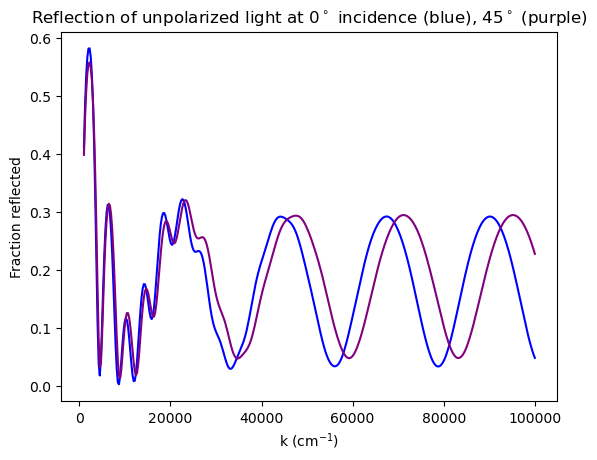

In [2]:
degree = pi/180
# list of layer thicknesses in nm
d_list = [inf,100,300,inf]
# list of refractive indices
n_list = [1,2.2,3.3+0.3j,1]
# list of wavenumbers to plot in nm^-1
ks=linspace(0.0001,.01,num=400)
# initialize lists of y-values to plot
Rnorm=[] 
R45=[]
for k in ks:
    # For normal incidence, s and p polarizations are identical.
    # I arbitrarily decided to use 's'.
    Rnorm.append(coh_tmm('s',n_list, d_list, 0, 1/k)['R'])
    R45.append(unpolarized_RT(n_list, d_list, 45*degree, 1/k)['R'])
kcm = ks * 1e7 #ks in cm^-1 rather than nm^-1
plt.figure()
plt.plot(kcm,Rnorm,'blue',kcm,R45,'purple')
plt.xlabel('k (cm$^{-1}$)')
plt.ylabel('Fraction reflected')
plt.title('Reflection of unpolarized light at 0$^\circ$ incidence (blue), '
            '45$^\circ$ (purple)');

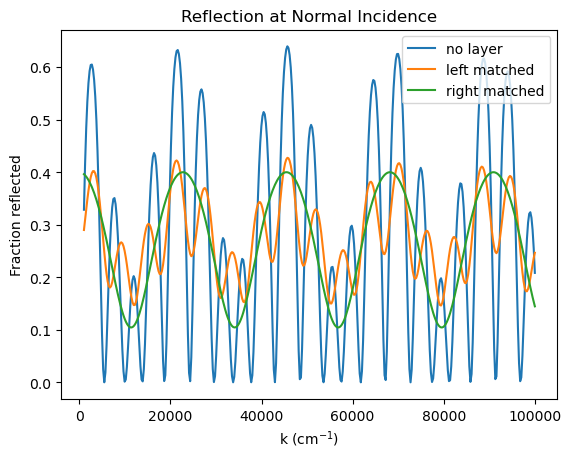

In [41]:
# list of layer thicknesses in nm
d_list3 = [inf, 100, 100, 100, 0, 100, inf]
# list of refractive indices
n_list3 = [1, 2.2, 3, 3, 3, 2.2, 1]
# list of coherences for each layer
c_list3 = ['i', 'c', 'c', 'c', 'i', 'c', 'i']

# list of layer thicknesses in nm
d_list2 = [inf, 100, 100, 100, 0, 100, inf]
# list of refractive indices
n_list2 = [1, 2.2, 3, 3, 2.2, 2.2, 1]
# list of coherences for each layer
c_list2 = ['i', 'c', 'c', 'c', 'i', 'c', 'i']

# list of layer thicknesses in nm
d_list = [inf, 100, 100, 100, 100, inf]
# list of refractive indices
n_list = [1, 2.2, 3, 3, 2.2, 1]
# list of coherences for each layer
c_list = ['i', 'c', 'c', 'c', 'c', 'i']

# list of wavenumbers to plot in nm^-1
ks=linspace(0.0001,.01,num=400)
# initialize lists of y-values to plot
Rnorm1=[] 
Rnorm2=[]
Rnorm3=[]
for k in ks:
    # For normal incidence, s and p polarizations are identical.
    # I arbitrarily decided to use 's'.
    Rnorm3.append(inc_tmm('s', n_list3, d_list3, c_list3, 0, 1/k)['R'])
    Rnorm1.append(inc_tmm('s', n_list, d_list, c_list, 0, 1/k)['R'])
    Rnorm2.append(inc_tmm('s', n_list2, d_list2, c_list2, 0, 1/k)['R'])
    #R45.append(unpolarized_RT(n_list, d_list, 45*degree, 1/k)['R'])
kcm = ks * 1e7 #ks in cm^-1 rather than nm^-1
plt.figure()
plt.plot(kcm,Rnorm1,kcm,Rnorm2, kcm, Rnorm3)
plt.xlabel('k (cm$^{-1}$)')
plt.ylabel('Fraction reflected')
plt.title('Reflection at Normal Incidence');
plt.legend(['no layer', 'left matched', "right matched"])